# AeroSpecML: Predicting Aircraft Max Speed from Scraped Specs

Predicting military aircraft top speed from physical and engine specs scraped from Wikipedia, using regularized linear regression (Ridge/Lasso/ElasticNet) tuned with GridSearchCV, with a Random Forest / XGBoost comparison to check whether a linear model is even the right tool for this data.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv("../data/aircraft_specs.csv")
print("Rows and Columns: ",df.shape)
df.info()

Rows and Columns:  (117, 19)
<class 'pandas.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   aircraft               117 non-null    str    
 1   crew                   81 non-null     float64
 2   length_ft              100 non-null    float64
 3   wingspan_ft            82 non-null     float64
 4   height_ft              96 non-null     float64
 5   wing_area_sqft         58 non-null     float64
 6   empty_weight_lb        88 non-null     float64
 7   gross_weight_lb        47 non-null     float64
 8   max_takeoff_weight_lb  86 non-null     float64
 9   engine_count           112 non-null    float64
 10  engine_thrust_lbf      42 non-null     float64
 11  engine_thrust_ab_lbf   12 non-null     float64
 12  max_speed_mach         23 non-null     float64
 13  max_speed_kts          61 non-null     float64
 14  cruise_speed_kts       48 non-null     f

In [7]:
df.describe()

,crew,length_ft,wingspan_ft,height_ft,wing_area_sqft,empty_weight_lb,gross_weight_lb,max_takeoff_weight_lb,engine_count,engine_thrust_lbf,engine_thrust_ab_lbf,max_speed_mach,max_speed_kts,cruise_speed_kts,combat_range_nmi,ferry_range_nmi,range_nmi,service_ceiling_ft
count,81.000000,100.000000,82.000000,96.000000,58.000000,88.000000,47.000000,86.000000,112.000000,42.000000,12.000000,23.000000,61.000000,48.000000,24.000000,31.000000,70.00000,96.000000
mean,4.086420,73.804200,81.501585,22.322396,1188.540517,50170.420455,80939.865957,126339.941860,2.142857,19762.071429,27560.000000,38.251957,319.827869,266.562500,799.416667,2613.161290,2295.00000,35261.458333
std,11.209591,47.047049,51.372920,14.083426,1419.431780,76495.304923,146067.983899,184987.968662,1.199528,15109.141764,10558.800724,176.955937,177.877319,142.351514,1328.994747,2017.759617,2443.85097,15399.742785
min,0.000000,8.200000,6.800000,4.000000,37.000000,81.000000,39.700000,58.000000,1.000000,990.000000,5000.000000,0.755000,33.000000,55.000000,110.000000,508.000000,50.00000,5000.000000
25%,1.000000,46.000000,42.000000,13.000000,250.825000,9839.500000,12285.000000,17340.000000,1.000000,9103.750000,23327.500000,0.877500,164.000000,151.750000,240.000000,1230.500000,539.25000,20000.000000
50%,2.000000,58.500000,58.625000,16.000000,608.000000,20252.500000,26500.000000,50350.000000,2.000000,16800.000000,28850.000000,0.975000,289.000000,239.000000,390.000000,2010.000000,1376.50000,34100.000000
75%,4.000000,97.000000,130.675000,33.250000,1745.000000,48300.000000,51770.000000,155000.000000,2.000000,26750.000000,31835.000000,1.925000,471.000000,414.250000,673.500000,2900.000000,2936.75000,50000.000000
max,100.000000,247.000000,222.000000,65.000000,6200.000000,410000.000000,800000.000000,840000.000000,8.000000,62000.000000,43000.000000,850.000000,746.000000,504.000000,6350.000000,9572.000000,12300.00000,80000.000000


In [8]:
df.head()

,aircraft,crew,length_ft,wingspan_ft,height_ft,wing_area_sqft,empty_weight_lb,gross_weight_lb,max_takeoff_weight_lb,engine_count,engine_thrust_lbf,engine_thrust_ab_lbf,max_speed_mach,max_speed_kts,cruise_speed_kts,combat_range_nmi,ferry_range_nmi,range_nmi,service_ceiling_ft
0,L3Harris OA-1K Skyraider II,NaN,37.5,59.25,13.0,401.0,7836.0,16000.0,NaN,1.0,NaN,NaN,NaN,213.0,180.0,NaN,NaN,1303.0,NaN
1,Fairchild Republic A-10 Thunderbolt II,1.0,53.0,57.00,14.0,506.0,24959.0,30384.0,46000.0,2.0,9065.0,NaN,NaN,381.0,300.0,NaN,2240.0,NaN,45000.0
2,Embraer EMB 314 Super Tucano,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EA-37B Compass Call,NaN,96.0,93.00,25.0,NaN,48300.0,NaN,98000.0,2.0,15385.0,NaN,0.82,NaN,NaN,NaN,NaN,NaN,45000.0
4,Rockwell B-1 Lancer,4.0,146.0,137.00,34.0,1950.0,192000.0,326000.0,477000.0,4.0,17390.0,30780.0,1.25,721.0,NaN,2993.0,NaN,5100.0,60000.0


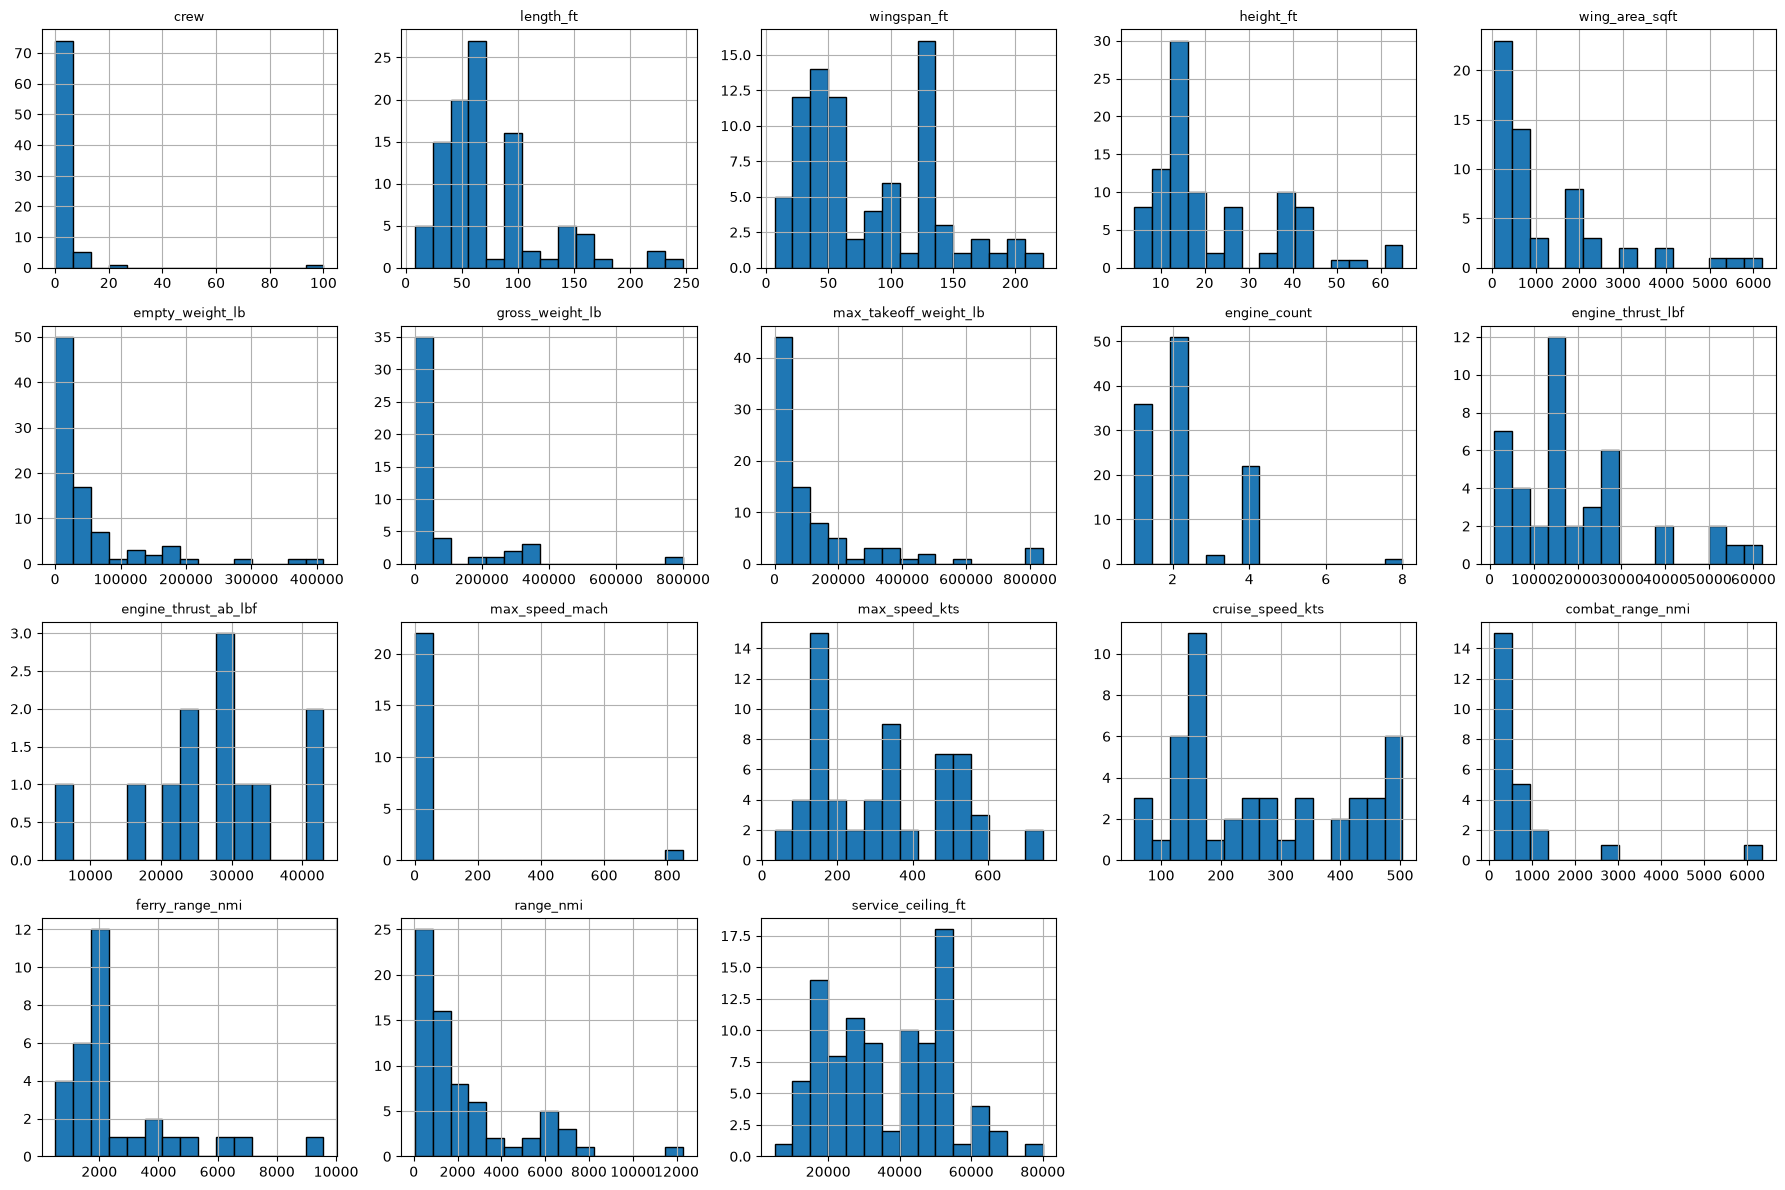

In [10]:
#Visualize distribution
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    df[col].dropna().hist(ax=ax, bins=15, edgecolor="black")
    ax.set_title(col, fontsize=9)
for ax in axes.flatten()[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

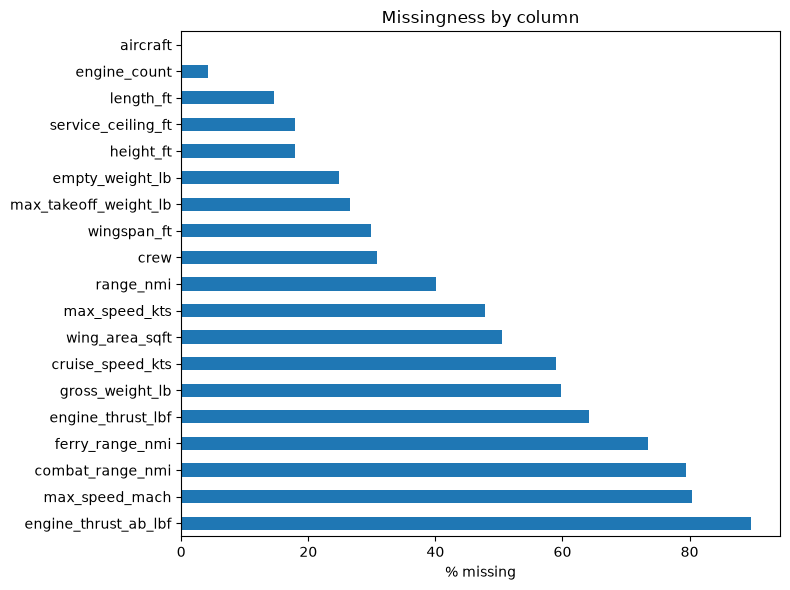

In [12]:
#missing data percentage
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
missing_pct.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missingness by column")
plt.tight_layout()
plt.show()

1. **Speed is split across two columns.** Fighters report `max_speed_mach`, everything else reports `max_speed_kts`. These need to become one target.
2. **Range is split across three columns** (`combat_range_nmi`, `ferry_range_nmi`, `range_nmi`), same story.

In [13]:
# Mach 1 varies with altitude. Most high-performance max-speed specs are quoted
# at high altitude (~36,000 ft), where the speed of sound is about 573.57 kts,
# not the ~661 kts you'd use at sea level. This is an approximation, not exact,
# since we don't know the exact altitude each spec was measured at.
MACH_TO_KTS_AT_ALTITUDE = 573.57

df["max_speed_combined_kts"] = df["max_speed_kts"].fillna(df["max_speed_mach"] * MACH_TO_KTS_AT_ALTITUDE)
print("rows with a usable speed target:", df["max_speed_combined_kts"].notna().sum())

rows with a usable speed target: 76


In [14]:
# no real aircraft on this list exceeds roughly Mach 4 at altitude (~2300 kts),
# so anything above that is treated as a parsing artifact, not a real reading
SPEED_SANITY_LIMIT_KTS = 2500

bad_rows = df[df["max_speed_combined_kts"] > SPEED_SANITY_LIMIT_KTS]
print("flagged as implausible:")
print(bad_rows[["aircraft", "max_speed_mach", "max_speed_kts", "max_speed_combined_kts"]])

df.loc[df["max_speed_combined_kts"] > SPEED_SANITY_LIMIT_KTS, "max_speed_combined_kts"] = np.nan

flagged as implausible:
                       aircraft  max_speed_mach  max_speed_kts  \
6  Northrop Grumman B-21 Raider           850.0            NaN   

   max_speed_combined_kts  
6                487534.5  


In [15]:
# same consolidation idea for range: prefer the plain "range" field, fall back
# to combat range, then ferry range, since not every aircraft reports all three
df["range_combined_nmi"] = (
    df["range_nmi"].fillna(df["combat_range_nmi"]).fillna(df["ferry_range_nmi"])
)
print("rows with a usable range value:", df["range_combined_nmi"].notna().sum())

rows with a usable range value: 82


In [16]:
df.head()

,aircraft,crew,length_ft,wingspan_ft,height_ft,wing_area_sqft,empty_weight_lb,gross_weight_lb,max_takeoff_weight_lb,engine_count,...,engine_thrust_ab_lbf,max_speed_mach,max_speed_kts,cruise_speed_kts,combat_range_nmi,ferry_range_nmi,range_nmi,service_ceiling_ft,max_speed_combined_kts,range_combined_nmi
0,L3Harris OA-1K Skyraider II,NaN,37.5,59.25,13.0,401.0,7836.0,16000.0,NaN,1.0,...,NaN,NaN,213.0,180.0,NaN,NaN,1303.0,NaN,213.0000,1303.0
1,Fairchild Republic A-10 Thunderbolt II,1.0,53.0,57.00,14.0,506.0,24959.0,30384.0,46000.0,2.0,...,NaN,NaN,381.0,300.0,NaN,2240.0,NaN,45000.0,381.0000,2240.0
2,Embraer EMB 314 Super Tucano,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EA-37B Compass Call,NaN,96.0,93.00,25.0,NaN,48300.0,NaN,98000.0,2.0,...,NaN,0.82,NaN,NaN,NaN,NaN,NaN,45000.0,470.3274,NaN
4,Rockwell B-1 Lancer,4.0,146.0,137.00,34.0,1950.0,192000.0,326000.0,477000.0,4.0,...,30780.0,1.25,721.0,NaN,2993.0,NaN,5100.0,60000.0,721.0000,5100.0


In [17]:
df = df.drop(columns=["engine_thrust_ab_lbf"])
print("columns remaining:", df.shape[1])

columns remaining: 20


In [18]:
df = df.dropna(subset=["max_speed_combined_kts"]).reset_index(drop=True)
print("rows with a usable target after cleaning:", len(df))

rows with a usable target after cleaning: 75
